# Predicting Conversion Rate

From our EDA, we know that our website's current conversion rate is 6.87%. Now we want to predict where a web session will convert into a purchase based on their activities

In [31]:
# Importing packages
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn import model_selection
from sklearn.model_selection import KFold
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

import sys
sys.path.append("..")
from fuzzy import helpers,charts

## Import and inspect the datasets

In [2]:
order_df = pd.read_csv("../data/processed_data/orders.csv")
session_df = pd.read_csv("../data/processed_data/website_sessions.csv")

In [3]:
order_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  str    
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
 8   hour                32313 non-null  int64  
 9   week_day            32313 non-null  int64  
 10  week_day_name       32313 non-null  str    
 11  day                 32313 non-null  int64  
 12  month               32313 non-null  int64  
 13  month_name          32313 non-null  str    
 14  date                32313 non-null  str    
 15  year                32313 non-null  int64  
dtypes: float64(2), 

In [4]:
session_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   website_session_id  472871 non-null  int64
 1   created_at          472871 non-null  str  
 2   user_id             472871 non-null  int64
 3   is_repeat_session   472871 non-null  int64
 4   utm_source          472871 non-null  str  
 5   utm_campaign        472871 non-null  str  
 6   utm_content         472871 non-null  str  
 7   device_type         472871 non-null  str  
 8   http_referer        472871 non-null  str  
 9   hour                472871 non-null  int64
 10  week_day            472871 non-null  int64
 11  week_day_name       472871 non-null  str  
 12  day                 472871 non-null  int64
 13  month               472871 non-null  int64
 14  month_name          472871 non-null  str  
 15  date                472871 non-null  str  
 16  year                472871 non-

In [5]:
combo_df = pd.merge(order_df[["website_session_id","order_id"]],session_df,on="website_session_id",how="right")
combo_df

,website_session_id,order_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,hour,week_day,week_day_name,day,month,month_name,date,year
0,1,NaN,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,8,0,Monday,19,3,March,2012-03-19,2012
1,2,NaN,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,8,0,Monday,19,3,March,2012-03-19,2012
2,3,NaN,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,8,0,Monday,19,3,March,2012-03-19,2012
3,4,NaN,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,8,0,Monday,19,3,March,2012-03-19,2012
4,5,NaN,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,9,0,Monday,19,3,March,2012-03-19,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472866,472867,NaN,2015-03-19 07:49:25,394314,0,gsearch,brand,g_ad_2,desktop,https://www.gsearch.com,7,3,Thursday,19,3,March,2015-03-19,2015
472867,472868,NaN,2015-03-19 07:54:36,394315,0,bsearch,nonbrand,b_ad_1,mobile,https://www.bsearch.com,7,3,Thursday,19,3,March,2015-03-19,2015
472868,472869,NaN,2015-03-19 07:55:40,394316,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,7,3,Thursday,19,3,March,2015-03-19,2015
472869,472870,NaN,2015-03-19 07:56:29,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,7,3,Thursday,19,3,March,2015-03-19,2015


## Target feature

In [6]:
# Create a converted column
# If a session has a non-null order_id, it converted into a purchase
combo_df['converted'] = combo_df['order_id'].notnull().astype(int)
combo_df = combo_df.fillna("unknown")

In [7]:
combo_df.columns

Index(['website_session_id', 'order_id', 'created_at', 'user_id',
       'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content',
       'device_type', 'http_referer', 'hour', 'week_day', 'week_day_name',
       'day', 'month', 'month_name', 'date', 'year', 'converted'],
      dtype='str')

## Quick EDA on Conversion Rate

In [8]:
def conversion_rate_by_var(df,var):
    converted_df = pd.DataFrame(df[df["converted"]==1].groupby(var).converted.count())
    total_df = pd.DataFrame(df.groupby(var).converted.count())
    total_df.columns = ["total_sessions"]
    converted_df = converted_df.merge(total_df,on=var)
    converted_df["conversion_rate"] = converted_df["converted"]/converted_df["total_sessions"]
    converted_df["conversion_rate"].plot.bar(title="Conversion rate",figsize=(5,3))
    

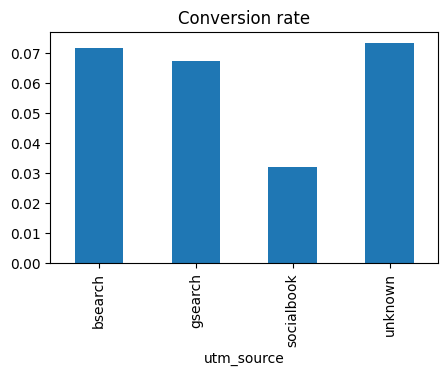

In [9]:
conversion_rate_by_var(combo_df,"utm_source")

- Conversion rate is high when customers enter our website from search engines like Google (gsearch) and Bing (bsearch) instead of Social Media
- We must look into our current running ads on Social Media to see whether it is attracting the right customers who will end up making purchases

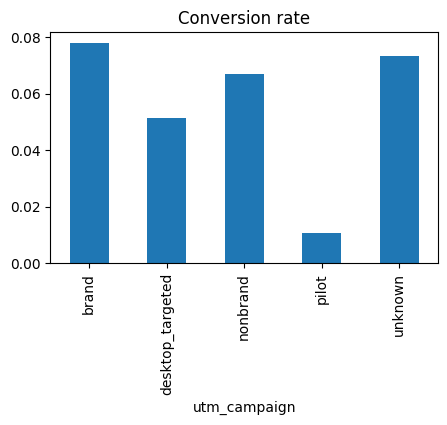

In [10]:
conversion_rate_by_var(combo_df,"utm_campaign")

- Conversion rate is higher for branded traffic even though, according to the EDA, non-branded traffic is way higher
- This means that even though more customer visits our website through non-brand searches, more of them ended up making a purchase when they found us through branded search.

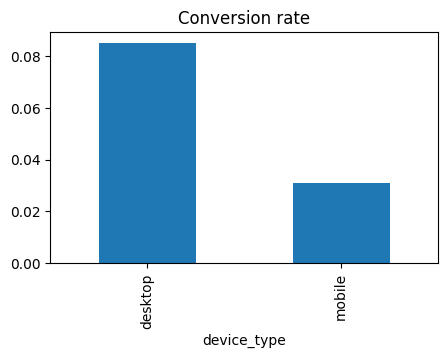

In [11]:
conversion_rate_by_var(combo_df,"device_type")

- Conversion rate is doubled among desktop users compared to mobile users
- The company should investigate why there is such a difference. Is the checkout UI on mobile not user-friendly? What is the bottle-neck that prevents users from making as many purchases on mobile

- Conversion rate is high during 11:00 - 15:00 in a day, on weekdays, and December - February in a year
- No clear correlation with days in a month

- Conversion rate has been steadily increasingn over the years => the business is doing well

## Feature Engineering

In [12]:
# Clean up unnecessary features
merge_df = combo_df[['utm_source','is_repeat_session', 'utm_campaign', 'utm_content','device_type', 'http_referer', 'hour', 'week_day', 'month', 'converted']]

In [13]:
# One-hot encoding for categorical variables
merge_df = pd.get_dummies(merge_df,dtype=int)

In [14]:
merge_df

,is_repeat_session,hour,week_day,month,converted,utm_source_bsearch,utm_source_gsearch,utm_source_socialbook,utm_source_unknown,utm_campaign_brand,...,utm_content_g_ad_2,utm_content_social_ad_1,utm_content_social_ad_2,utm_content_unknown,device_type_desktop,device_type_mobile,http_referer_https://www.bsearch.com,http_referer_https://www.gsearch.com,http_referer_https://www.socialbook.com,http_referer_unknown
0,0,8,0,3,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,8,0,3,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2,0,8,0,3,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
3,0,8,0,3,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,0,9,0,3,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472866,0,7,3,3,0,0,1,0,0,1,...,1,0,0,0,1,0,0,1,0,0
472867,0,7,3,3,0,1,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
472868,0,7,3,3,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
472869,0,7,3,3,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0


## Splitting data

In [15]:
from sklearn.model_selection import train_test_split


X = merge_df.drop(["converted"],axis=1)
y = merge_df["converted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=71)
print(f"Training set: {len(X_train),2}")
print(f"Validation set: {len(X_val),2}")
print(f"Test set: {len(X_test),2}")


Training set: (383024, 2)
Validation set: (42559, 2)
Test set: (47288, 2)


## Building prediction model

### Baseline

In [ ]:
models = []

models.append(("lr",LogisticRegression(l1_ratio=0,solver="newton-cholesky",max_iter=1000)))
models.append(("xgb",xgb.XGBClassifier()))
models.append(("bal_rf",BalancedRandomForestClassifier()))

k = 5
random_seed = 71
for name,model in models:
    kfold = KFold(n_splits=k,random_state=random_seed,shuffle=True)
    cv_results = model_selection.cross_val_score(model,X_train,y_train,cv=kfold,scoring="roc_auc")

    y_train_pred = model.fit(X_train,y_train).predict(X_train)
    cm = confusion_matrix(y_train, y_train_pred)
    cr = classification_report(y_train, y_train_pred)
    print(f"{name}:\nTrain AUC: {cv_results.mean():.4f}\nTrain Confusion matrix:\n{cm}\n{cr}------")


/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

lr:
Train AUC: 0.6124
Train Confusion matrix:
[[356962      0]
 [ 26062      0]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96    356962
           1       0.00      0.00      0.00     26062

    accuracy                           0.93    383024
   macro avg       0.47      0.50      0.48    383024
weighted avg       0.87      0.93      0.90    383024
------


/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

xgb:
Train AUC: 0.6026
Train Confusion matrix:
[[356962      0]
 [ 26062      0]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96    356962
           1       0.00      0.00      0.00     26062

    accuracy                           0.93    383024
   macro avg       0.47      0.50      0.48    383024
weighted avg       0.87      0.93      0.90    383024
------
bal_rf:
Train AUC: 0.5687
Train Confusion matrix:
[[205177 151785]
 [  5031  21031]]
              precision    recall  f1-score   support

           0       0.98      0.57      0.72    356962
           1       0.12      0.81      0.21     26062

    accuracy                           0.59    383024
   macro avg       0.55      0.69      0.47    383024
weighted avg       0.92      0.59      0.69    383024
------


- LR and XGB are classifying most of the sample as negative and since it is the majority class their AUC is higher and the performance metrics for the negative class is high. But these are not actually good performace
- Balanced RF is casting a wide net and can identify most of the positive cases but at the cost of many false alarms

### Addressing class imbalance with class weights

<Axes: xlabel='converted'>

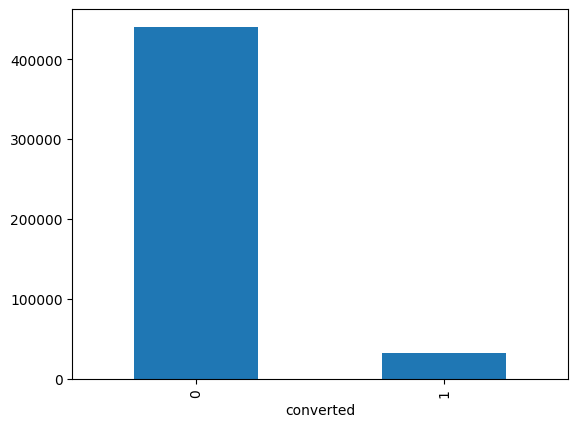

In [140]:
# Show class distribution
merge_df.groupby("converted").size().plot.bar()

In [141]:

class_weights= {}
class_weights[0] = len(merge_df)/(2*len(merge_df[merge_df["converted"]==0]))
class_weights[1] = len(merge_df)/(2*len(merge_df[merge_df["converted"]==1]))


In [142]:
# scale_pos_weight for XGB
xgb_weight = round(len(merge_df[merge_df["converted"]==0])/len(merge_df[merge_df["converted"]==1]),4)
xgb_weight

13.6341

In [143]:
cw_models = []
cw_results = []

cw_models.append(("lr",LogisticRegression(l1_ratio=0,class_weight=class_weights,solver="newton-cholesky",max_iter=1000)))
cw_models.append(("xgb",xgb.XGBClassifier(scale_pos_weight=xgb_weight)))
cw_models.append(("rf",BalancedRandomForestClassifier(class_weight=class_weights)))

k = 5
random_seed = 71
for name,model in cw_models:
    kfold = KFold(n_splits=k,random_state=random_seed,shuffle=True)
    cv_results = model_selection.cross_val_score(model,X_train,y_train,cv=kfold,scoring="roc_auc")
    cw_results.append(cv_results)

    y_train_pred = model.fit(X_train,y_train).predict(X_train)
    cm = confusion_matrix(y_train, y_train_pred)
    cr = classification_report(y_train, y_train_pred)
    print(f"{name}:\nTrain AUC: {cv_results.mean():.4f}\nTrain Confusion matrix:\n{cm}\n{cr}------")



lr:
Train AUC: 0.6124
Train Confusion matrix:
[[119062 237900]
 [  3918  22144]]
              precision    recall  f1-score   support

           0       0.97      0.33      0.50    356962
           1       0.09      0.85      0.15     26062

    accuracy                           0.37    383024
   macro avg       0.53      0.59      0.33    383024
weighted avg       0.91      0.37      0.47    383024
------
xgb:
Train AUC: 0.6011
Train Confusion matrix:
[[163288 193674]
 [  5933  20129]]
              precision    recall  f1-score   support

           0       0.96      0.46      0.62    356962
           1       0.09      0.77      0.17     26062

    accuracy                           0.48    383024
   macro avg       0.53      0.61      0.39    383024
weighted avg       0.91      0.48      0.59    383024
------
rf:
Train AUC: 0.5573
Train Confusion matrix:
[[ 99456 257506]
 [    63  25999]]
              precision    recall  f1-score   support

           0       1.00      0.28  

- All models are encountering the same issues that Balanced RF faced in the baseline experiment
- They are casting a wide net and could identify most of the positive cases but there are many false positives too
- This drags down the recall score of the negative class

### Undersampling

In [144]:
print(f"Negative class size: {len(merge_df[merge_df["converted"]==0])}")
print(f"Positive class size: {len(merge_df[merge_df["converted"]==1])}")
print(f"Positive class percentage: {(len(merge_df[merge_df["converted"]==1])/len(merge_df)*100)}")

Negative class size: 440558
Positive class size: 32313
Positive class percentage: 6.833364702001179


In [146]:
rus = RandomUnderSampler(sampling_strategy="majority", random_state=71)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# Check the new distribution
print(f"Resampled dataset shape: {Counter(y_resampled)}")

Resampled dataset shape: Counter({0: 26062, 1: 26062})


In [ ]:
# Baseline models with undersampled training data
models = []

models.append(("lr",LogisticRegression(l1_ratio=0,solver="newton-cholesky",max_iter=1000)))
models.append(("xgb",xgb.XGBClassifier()))
models.append(("bal_rf",BalancedRandomForestClassifier()))

k = 5
random_seed = 71
for name,model in models:
    kfold = KFold(n_splits=k,random_state=random_seed,shuffle=True)
    cv_results = model_selection.cross_val_score(model,X_resampled,y_resampled,cv=kfold,scoring="roc_auc")

    y_train_pred = model.fit(X_resampled,y_resampled).predict(X_resampled)
    cm = confusion_matrix(y_resampled, y_train_pred)
    cr = classification_report(y_resampled, y_train_pred)
    print(f"{name}:\nTrain AUC: {cv_results.mean():.4f}\nTrain Confusion matrix:\n{cm}\n{cr}------")


lr:
Train AUC: 0.6107
Train Confusion matrix:
[[ 8665 17397]
 [ 3918 22144]]
              precision    recall  f1-score   support

           0       0.69      0.33      0.45     26062
           1       0.56      0.85      0.68     26062

    accuracy                           0.59     52124
   macro avg       0.62      0.59      0.56     52124
weighted avg       0.62      0.59      0.56     52124
------
xgb:
Train AUC: 0.5926
Train Confusion matrix:
[[13314 12748]
 [ 6558 19504]]
              precision    recall  f1-score   support

           0       0.67      0.51      0.58     26062
           1       0.60      0.75      0.67     26062

    accuracy                           0.63     52124
   macro avg       0.64      0.63      0.62     52124
weighted avg       0.64      0.63      0.62     52124
------
bal_rf:
Train AUC: 0.5539
Train Confusion matrix:
[[17991  8071]
 [ 6204 19858]]
              precision    recall  f1-score   support

           0       0.74      0.69      0.72

- Despite achieving the lowest AUC, Balanced Random Forest model shows very promising Precision and Recall for the positive class
- The goal is to detect all the high-intent customers (high recall) and to not waste resource on web visitors that won't end up making a purchase (high precision)
- Balanced RF is the best performer out of the 3 in balancing a high recall and decent precision.

### Predict validation set

In [148]:
winner_model = BalancedRandomForestClassifier().fit(X_resampled,y_resampled)
y_val_pred = winner_model.predict(X_val)

In [149]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.94      0.51      0.67     39609
           1       0.08      0.57      0.14      2950

    accuracy                           0.52     42559
   macro avg       0.51      0.54      0.40     42559
weighted avg       0.88      0.52      0.63     42559



In [150]:
cm = confusion_matrix(y_val, y_val_pred)
cm

array([[20376, 19233],
       [ 1257,  1693]])

In [151]:
from sklearn.metrics import roc_auc_score
y_val_probs = winner_model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_val_probs)

print(f"Validation AUC: {val_auc:.4f}")

Validation AUC: 0.5557


- The Balanced RF model didn't overfit as its train and validation AUC are similar
- But it also didn't generalize well on the validation set with precison=0.08 and recall=0.56 for the positive class
- This means we are able to detect the majority of high-intent customers but at the cost of a massive number of false alarms.

## Adding pages viewed

In [16]:
views_df = pd.read_csv("../data/processed_data/website_pageviews.csv")
views_df = views_df[["website_session_id","pageview_url"]]

In [18]:
views_df = views_df.groupby("website_session_id")[["pageview_url"]].agg(','.join).reset_index()
multi_page = views_df['pageview_url'].str.get_dummies(sep=',')
multi_page_df = result = pd.concat([views_df[['website_session_id']], multi_page], axis=1)
multi_page_df = multi_page_df.drop([ '/cart','/shipping','/thank-you-for-your-order','/billing','/billing-2'],axis=1)
multi_page_df['total_page_viewed'] = multi_page_df.sum(axis=1)
multi_page_df.head()

,website_session_id,/home,/lander-1,/lander-2,/lander-3,/lander-4,/lander-5,/products,/the-birthday-sugar-panda,/the-forever-love-bear,/the-hudson-river-mini-bear,/the-original-mr-fuzzy,total_page_viewed
0,1,1,0,0,0,0,0,0,0,0,0,0,2
1,2,1,0,0,0,0,0,0,0,0,0,0,3
2,3,1,0,0,0,0,0,0,0,0,0,0,4
3,4,1,0,0,0,0,0,0,0,0,0,0,5
4,5,1,0,0,0,0,0,0,0,0,0,0,6


In [19]:
multi_page_df.shape

(472871, 13)

In [20]:
combo_df.shape

(472871, 19)

In [21]:
merge_view_df = pd.merge(combo_df,multi_page_df,on="website_session_id")
merge_view_df = merge_view_df.drop(['website_session_id','order_id', 'created_at', 'user_id','week_day_name','month_name', 'date', 'year','day'],axis=1)

In [22]:
merge_view_df = pd.get_dummies(merge_view_df,dtype=int)
merge_view_df.columns

Index(['is_repeat_session', 'hour', 'week_day', 'month', 'converted', '/home',
       '/lander-1', '/lander-2', '/lander-3', '/lander-4', '/lander-5',
       '/products', '/the-birthday-sugar-panda', '/the-forever-love-bear',
       '/the-hudson-river-mini-bear', '/the-original-mr-fuzzy',
       'total_page_viewed', 'utm_source_bsearch', 'utm_source_gsearch',
       'utm_source_socialbook', 'utm_source_unknown', 'utm_campaign_brand',
       'utm_campaign_desktop_targeted', 'utm_campaign_nonbrand',
       'utm_campaign_pilot', 'utm_campaign_unknown', 'utm_content_b_ad_1',
       'utm_content_b_ad_2', 'utm_content_g_ad_1', 'utm_content_g_ad_2',
       'utm_content_social_ad_1', 'utm_content_social_ad_2',
       'utm_content_unknown', 'device_type_desktop', 'device_type_mobile',
       'http_referer_https://www.bsearch.com',
       'http_referer_https://www.gsearch.com',
       'http_referer_https://www.socialbook.com', 'http_referer_unknown'],
      dtype='str')

In [23]:
merge_view_df.corr()['converted'].sort_values(ascending=False).head(10)

converted                      1.000000
/products                      0.243766
/the-original-mr-fuzzy         0.225088
/the-forever-love-bear         0.111124
device_type_desktop            0.099050
/the-birthday-sugar-panda      0.075305
/lander-5                      0.054213
/the-hudson-river-mini-bear    0.045550
total_page_viewed              0.043364
/lander-2                      0.021803
Name: converted, dtype: float64

In [24]:
X = merge_view_df.drop(["converted"],axis=1)
y = merge_view_df["converted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 425583
Test set size: 47288


In [29]:

model = BalancedRandomForestClassifier()

k=5
random_seed = 82
kfold = KFold(n_splits=k,random_state=random_seed,shuffle=True)
cv_results = model_selection.cross_val_score(model,X_train,y_train,cv=kfold,scoring="roc_auc")

y_train_pred = model.fit(X_train,y_train).predict(X_train)
cm = confusion_matrix(y_train, y_train_pred)
cr = classification_report(y_train, y_train_pred)
print(f"\nTrain AUC: {cv_results.mean():.4f}\nTrain Confusion matrix:\n{cm}\n{cr}------")


Train AUC: 0.8108
Train Confusion matrix:
[[297565  99006]
 [     0  29012]]
              precision    recall  f1-score   support

           0       1.00      0.75      0.86    396571
           1       0.23      1.00      0.37     29012

    accuracy                           0.77    425583
   macro avg       0.61      0.88      0.61    425583
weighted avg       0.95      0.77      0.82    425583
------


In [32]:
rus = RandomUnderSampler(sampling_strategy="majority", random_state=71)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# Check the new distribution
print(f"Resampled dataset shape: {Counter(y_resampled)}")

Resampled dataset shape: Counter({0: 29012, 1: 29012})


In [33]:
model = BalancedRandomForestClassifier()

kfold = KFold(n_splits=k,random_state=random_seed,shuffle=True)
cv_results = model_selection.cross_val_score(model,X_resampled,y_resampled,cv=kfold,scoring="roc_auc")

y_train_pred = model.fit(X_resampled,y_resampled).predict(X_resampled)
cm = confusion_matrix(y_resampled, y_train_pred)
cr = classification_report(y_resampled, y_train_pred)
print(f"\nTrain AUC: {cv_results.mean():.4f}\nTrain Confusion matrix:\n{cm}\n{cr}------")


Train AUC: 0.8112
Train Confusion matrix:
[[29009     3]
 [    0 29012]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29012
           1       1.00      1.00      1.00     29012

    accuracy                           1.00     58024
   macro avg       1.00      1.00      1.00     58024
weighted avg       1.00      1.00      1.00     58024
------


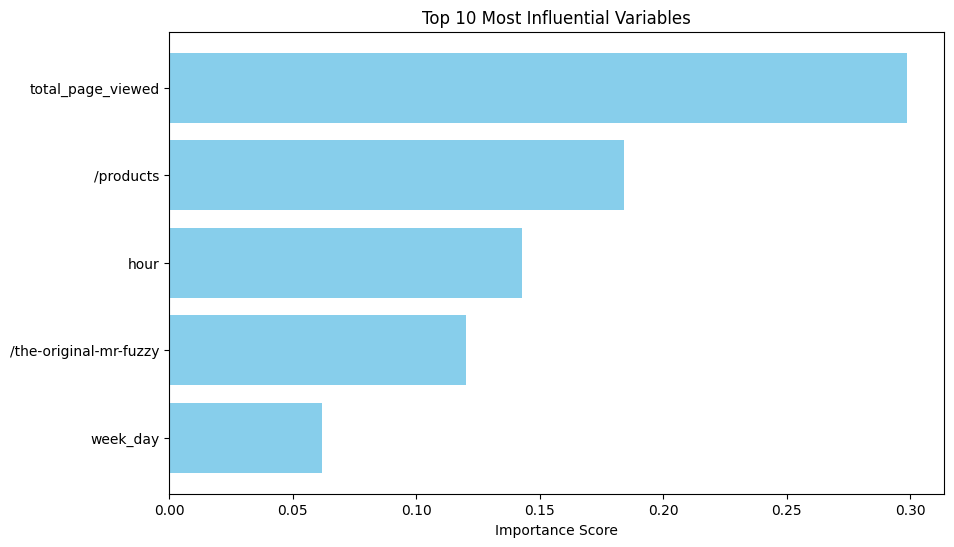

In [34]:
# 1. Extract importances
importances = model.feature_importances_
feature_names = X_train.columns

# 2. Create a tidy DataFrame
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# 3. Plot the top 10
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'].head(5), feature_df['Importance'].head(5), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Influential Variables')
plt.xlabel('Importance Score')
plt.show()

- Factors that likely lead 

### Predict test set

In [35]:
model = BalancedRandomForestClassifier().fit(X_resampled,y_resampled)
y_pred = model.predict(X_test)

In [38]:
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
cr_dict = classification_report(y_test, y_pred,output_dict=True)
print(f"\nTest AUC: {cv_results.mean():.4f}\nTest Confusion matrix:\n{cm}\n{cr}------")


Test AUC: 0.8112
Test Confusion matrix:
[[30266 13721]
 [  600  2701]]
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     43987
           1       0.16      0.82      0.27      3301

    accuracy                           0.70     47288
   macro avg       0.57      0.75      0.54     47288
weighted avg       0.92      0.70      0.77     47288
------


In [41]:
cr_dict["1"]["precision"]

0.16447448544635246

In [42]:
conversion_rate = len(merge_view_df[merge_view_df["converted"]==1])/len(merge_view_df)
test_precision = cr_dict["1"]["precision"]
lift = test_precision/conversion_rate
print(f"Lift: {lift:.2f}")

Lift: 2.41
